# Image Extraction from Parquet File

This notebook demonstrates how to extract images stored in a Parquet file.
## 1. Install Required Packages
First, let's ensure we have all the necessary packages installed.
"""




In [1]:
!pip install pandas pyarrow pillow matplotlib

In [2]:
import pandas as pd
import pyarrow.parquet as pq
from PIL import Image
import io
import matplotlib.pyplot as plt
import os
import numpy as np
from base64 import b64decode

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
data_path = '/content/drive/MyDrive/data'
train_parquet = os.path.join(data_path, 'train.parquet')

try:
    df = pd.read_parquet(train_parquet)
    print("Parquet file loaded successfully!")
    print(f"Number of rows: {len(df)}")
    print("\nColumns:")
    print(df.columns.tolist())
except Exception as e:
    print(f"Error loading parquet file: {e}")

Parquet file loaded successfully!
Number of rows: 3350

Columns:
['image', 'label']


In [10]:
def extract_image_bytes(row):
    """Extract image bytes from the dictionary in the 'image' column"""
    try:
        return row['image']['bytes']
    except (KeyError, TypeError) as e:
        print(f"Error extracting bytes: {e}")
        return None

# Add a new column with just the bytes
df['image_bytes'] = df.apply(extract_image_bytes, axis=1)

# Show the modified dataframe
df.head()

,image,label,image_bytes
0,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,3,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
1,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
2,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
3,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,1,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...
4,{'bytes': b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x...,0,b'\xff\xd8\xff\xe0\x00\x10JFIF\x00\x01\x01\x00...


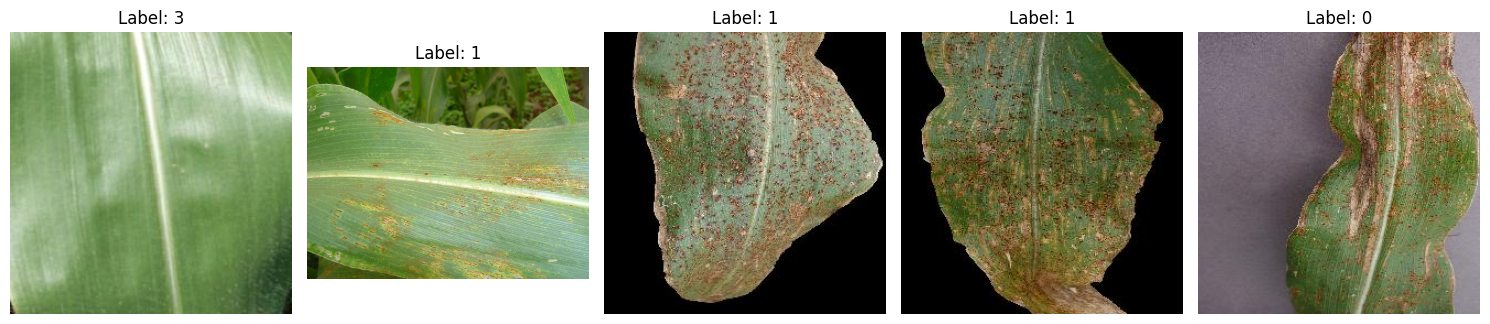

In [11]:
def display_sample_images(df, num_samples=5):
    """Display sample images with their labels"""
    plt.figure(figsize=(15, 10))
    for i in range(min(num_samples, len(df))):
        try:
            img_bytes = df.iloc[i]['image_bytes']
            if img_bytes is None:
                continue

            img = Image.open(io.BytesIO(img_bytes))
            plt.subplot(1, num_samples, i+1)
            plt.imshow(img)
            plt.title(f"Label: {df.iloc[i]['label']}")
            plt.axis('off')
        except Exception as e:
            print(f"Error displaying image {i}: {e}")
    plt.tight_layout()
    plt.show()

# Display 5 sample images
display_sample_images(df, 5)

In [13]:
def save_all_images(df, output_dir="/content/drive/MyDrive/extracted_images", format="jpg"):
    """
    Save all images to disk with their labels in the filename
    Format: image_[index]_label_[label].[format]
    """
    os.makedirs(output_dir, exist_ok=True)

    for i, row in df.iterrows():
        try:
            if row['image_bytes'] is None:
                continue

            img = Image.open(io.BytesIO(row['image_bytes']))
            output_path = os.path.join(
                output_dir,
                f"image_{i}_label_{row['label']}.{format}"
            )
            img.save(output_path)
            print(f"Saved {output_path}")
        except Exception as e:
            print(f"Error saving image {i}: {e}")

# Save all images
save_all_images(df)



Saved /content/drive/MyDrive/extracted_images/image_0_label_3.jpg
Saved /content/drive/MyDrive/extracted_images/image_1_label_1.jpg
Saved /content/drive/MyDrive/extracted_images/image_2_label_1.jpg
Saved /content/drive/MyDrive/extracted_images/image_3_label_1.jpg
Saved /content/drive/MyDrive/extracted_images/image_4_label_0.jpg
Saved /content/drive/MyDrive/extracted_images/image_5_label_1.jpg
Saved /content/drive/MyDrive/extracted_images/image_6_label_2.jpg
Saved /content/drive/MyDrive/extracted_images/image_7_label_2.jpg
Saved /content/drive/MyDrive/extracted_images/image_8_label_3.jpg
Saved /content/drive/MyDrive/extracted_images/image_9_label_2.jpg
Saved /content/drive/MyDrive/extracted_images/image_10_label_0.jpg
Saved /content/drive/MyDrive/extracted_images/image_11_label_0.jpg
Saved /content/drive/MyDrive/extracted_images/image_12_label_0.jpg
Saved /content/drive/MyDrive/extracted_images/image_13_label_1.jpg
Saved /content/drive/MyDrive/extracted_images/image_14_label_1.jpg
Saved

In [14]:
import os
from PIL import Image
import io

def save_images_by_label(df, output_dir="/content/drive/MyDrive/unity_images", samples_per_label=100):
    """
    Save images grouped by label, with exactly 100 images per label.

    Args:
        df: DataFrame containing 'image_bytes' and 'label' columns
        output_dir: Root directory to save images
        samples_per_label: Number of images to save per label (default: 100)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)

    # Group by label
    grouped = df.groupby('label')

    for label, group in grouped:
        # Create subdirectory for this label
        label_dir = os.path.join(output_dir, str(label))
        os.makedirs(label_dir, exist_ok=True)

        # Counter for this label
        count = 0

        for i, row in group.iterrows():
            if count >= samples_per_label:
                break

            try:
                if row['image_bytes'] is None:
                    continue

                img = Image.open(io.BytesIO(row['image_bytes']))
                output_path = os.path.join(label_dir, f"image_{i}.jpg")
                img.save(output_path)
                count += 1
                print(f"Saved {output_path} (Label {label}, {count}/{samples_per_label})")

            except Exception as e:
                print(f"Error saving image {i} (Label {label}): {e}")

        print(f"\nFinished saving {count} images for label {label}\n")

# Usage
save_images_by_label(df)

Saved /content/drive/MyDrive/unity_images/0/image_4.jpg (Label 0, 1/100)
Saved /content/drive/MyDrive/unity_images/0/image_10.jpg (Label 0, 2/100)
Saved /content/drive/MyDrive/unity_images/0/image_11.jpg (Label 0, 3/100)
Saved /content/drive/MyDrive/unity_images/0/image_12.jpg (Label 0, 4/100)
Saved /content/drive/MyDrive/unity_images/0/image_18.jpg (Label 0, 5/100)
Saved /content/drive/MyDrive/unity_images/0/image_21.jpg (Label 0, 6/100)
Saved /content/drive/MyDrive/unity_images/0/image_22.jpg (Label 0, 7/100)
Saved /content/drive/MyDrive/unity_images/0/image_24.jpg (Label 0, 8/100)
Saved /content/drive/MyDrive/unity_images/0/image_25.jpg (Label 0, 9/100)
Saved /content/drive/MyDrive/unity_images/0/image_29.jpg (Label 0, 10/100)
Saved /content/drive/MyDrive/unity_images/0/image_31.jpg (Label 0, 11/100)
Saved /content/drive/MyDrive/unity_images/0/image_39.jpg (Label 0, 12/100)
Saved /content/drive/MyDrive/unity_images/0/image_42.jpg (Label 0, 13/100)
Saved /content/drive/MyDrive/unity_